In [8]:
import pandas as pd
import numpy as np
import pickle

In [2]:
listi = pd.read_csv("../data/London/listings.csv")
listi

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,13913,https://www.airbnb.com/rooms/13913,20250914034649,2025-09-16,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,4.87,4.78,4.78,NaN,f,2,1,1,0,0.30
1,15400,https://www.airbnb.com/rooms/15400,20250914034649,2025-09-16,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,...,4.84,4.93,4.74,NaN,f,1,1,0,0,0.51
2,17402,https://www.airbnb.com/rooms/17402,20250914034649,2025-09-16,city scrape,Very Central Modern 3-Bed/2 Bath By Oxford St W1,"You'll have a great time in this beautiful, cl...","Fitzrovia is a very desirable trendy, arty and...",https://a0.muscache.com/pictures/39d5309d-fba7...,67564,...,4.72,4.89,4.61,NaN,f,2,2,0,0,0.32
3,24328,https://www.airbnb.com/rooms/24328,20250914034649,2025-09-18,previous scrape,Battersea live/work artist house,"Artist house by SW Battersea Park, bright high...","- Battersea is a quiet family area, easy acces...",https://a0.muscache.com/pictures/9194b40f-c627...,41759,...,4.93,4.60,4.65,NaN,f,1,1,0,0,0.53
4,36274,https://www.airbnb.com/rooms/36274,20250914034649,2025-09-15,city scrape,Bright 1 bedroom apt off brick lane in Shoreditch,*Update June '25- Pump Installed to improve wa...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,133271,...,4.46,4.85,4.54,NaN,t,2,2,0,0,0.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96866,1508894090797273412,https://www.airbnb.com/rooms/1508894090797273412,20250914034649,2025-09-16,city scrape,"Blueground | Finsbury, balcony, nr St. Paul's",Feel at home wherever you choose to live with ...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,314162972,...,NaN,NaN,NaN,NaN,t,405,405,0,0,NaN
96867,1508900042872179492,https://www.airbnb.com/rooms/1508900042872179492,20250914034649,2025-09-15,city scrape,Self-Contained Studio in Heart of Tooting Broa...,Welcome to your perfect London stay - The Lond...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,718690455,...,5.00,5.00,5.00,NaN,f,1,1,0,0,2.00
96868,1508926597927944565,https://www.airbnb.com/rooms/1508926597927944565,20250914034649,2025-09-14,city scrape,One bedroom apartment Dagenham,"Modern 1-bedroom apartment in Kerwin House, Da...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,389056540,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
96869,1508962439633147670,https://www.airbnb.com/rooms/1508962439633147670,20250914034649,2025-09-15,city scrape,Short Stay,Take it easy at this unique and tranquil getaway.,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,683246718,...,NaN,NaN,NaN,NaN,f,1,0,1,0,NaN


In [3]:
listi.shape

(96871, 79)

In [4]:
listi.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [5]:
important_cols = [
    "id",
    "price",
    "number_of_reviews",
    "review_scores_rating",
    "host_identity_verified",
    "host_has_profile_pic",
    "host_since",
    "host_response_rate",
    "latitude",
    "longitude",
    "description",
    "amenities",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "instant_bookable"
]

listi = listi[important_cols]

In [6]:
listi.shape

(96871, 19)

In [7]:
listi.head()

,id,price,number_of_reviews,review_scores_rating,host_identity_verified,host_has_profile_pic,host_since,host_response_rate,latitude,longitude,description,amenities,accommodates,bathrooms,bedrooms,room_type,property_type,neighbourhood_cleansed,instant_bookable
0,13913,$70.00,55,4.85,t,t,2009-11-16,100%,51.56861,-0.11270,My bright double bedroom with a large window h...,"[""Self check-in"", ""Kitchen"", ""Smoke alarm"", ""D...",1,1.0,1.0,Private room,Private room in rental unit,Islington,f
1,15400,$149.00,97,4.80,t,t,2009-12-05,NaN,51.48780,-0.16813,Lots of windows and light. St Luke's Gardens ...,"[""Kitchen"", ""Smoke alarm"", ""Dedicated workspac...",2,1.0,1.0,Entire home/apt,Entire rental unit,Kensington and Chelsea,f
2,17402,$411.00,56,4.77,t,t,2010-01-04,88%,51.52195,-0.14094,"You'll have a great time in this beautiful, cl...","[""Kitchen"", ""Cleaning products"", ""Smoke alarm""...",6,2.0,3.0,Entire home/apt,Entire rental unit,Westminster,f
3,24328,NaN,95,4.90,t,t,2009-09-28,100%,51.47072,-0.16266,"Artist house by SW Battersea Park, bright high...","[""Self check-in"", ""Kitchen"", ""Apple speaker Bl...",2,NaN,1.0,Entire home/apt,Entire townhouse,Wandsworth,f
4,36274,$210.00,15,4.53,t,t,2010-05-27,100%,51.52322,-0.06979,*Update June '25- Pump Installed to improve wa...,"[""Washer"", ""Kitchen"", ""TV with standard cable""...",4,1.0,1.0,Entire home/apt,Entire condo,Tower Hamlets,t


In [8]:
#listi["price"] = listi["price"].replace("[$,]", "", regex=True).astype(float)
listi.loc[:, "price"] = listi["price"].replace("[$,]", "", regex=True).astype(float)
listi["price"].head()

0     70.0
1    149.0
2    411.0
3      NaN
4    210.0
Name: price, dtype: object

In [9]:
listi["price"].dtype

dtype('O')

In [10]:
print("review_scores_rating: ",listi["review_scores_rating"].dtype)
print("price: ",listi["price"].dtype)
print("bathrooms: ",listi["bathrooms"].dtype)
print("host_response_rate: ",listi["host_response_rate"].dtype)
print("description: ",listi["description"].dtype)
print("bedrooms: ",listi["bedrooms"].dtype)

review_scores_rating:  float64
price:  object
bathrooms:  float64
host_response_rate:  object
description:  object
bedrooms:  float64


In [11]:
listi.isnull().sum()

id                            0
price                     34908
number_of_reviews             0
review_scores_rating      24122
host_identity_verified       41
host_has_profile_pic         41
host_since                   41
host_response_rate        31707
latitude                      0
longitude                     0
description                2450
amenities                     0
accommodates                  0
bathrooms                 34846
bedrooms                  12775
room_type                     0
property_type                 0
neighbourhood_cleansed        0
instant_bookable              0
dtype: int64

In [12]:
listi.isnull().sum().sort_values(ascending=False)

price                     34908
bathrooms                 34846
host_response_rate        31707
review_scores_rating      24122
bedrooms                  12775
description                2450
host_has_profile_pic         41
host_since                   41
host_identity_verified       41
number_of_reviews             0
id                            0
longitude                     0
latitude                      0
accommodates                  0
amenities                     0
room_type                     0
property_type                 0
neighbourhood_cleansed        0
instant_bookable              0
dtype: int64

# fill numeric columns with median
listi["review_scores_rating"].fillna(listi["review_scores_rating"].median(), inplace=True)

listi["bathrooms"].fillna(listi["bathrooms"].median(), inplace=True)

listi["bedrooms"].fillna(listi["bedrooms"].median(), inplace=True)

# fill description with empty string
listi["description"].fillna("", inplace=True)

In [13]:
listi = listi.copy()
# fill numeric columns with median
listi.loc[:, "review_scores_rating"] = listi["review_scores_rating"].fillna(listi["review_scores_rating"].median())

listi.loc[:, "bathrooms"] = listi["bathrooms"].fillna(listi["bathrooms"].median())

listi.loc[:, "bedrooms"] = listi["bedrooms"].fillna(listi["bedrooms"].median())

# fill description
listi.loc[:, "description"] = listi["description"].fillna("")

In [14]:
#Remove NAN rows of Price Column
listi = listi.dropna(subset=["price"])
listi["price"].isnull().sum()

np.int64(0)

In [15]:
listi.isnull().sum().sort_values(ascending=False)

host_response_rate        6306
host_identity_verified      25
host_since                  25
host_has_profile_pic        25
number_of_reviews            0
id                           0
price                        0
review_scores_rating         0
latitude                     0
longitude                    0
description                  0
amenities                    0
accommodates                 0
bathrooms                    0
bedrooms                     0
room_type                    0
property_type                0
neighbourhood_cleansed       0
instant_bookable             0
dtype: int64

In [16]:
# fill boolean columns with 0 (not verified / no profile pic)
listi["host_identity_verified"] = listi["host_identity_verified"].fillna("f")
listi["host_has_profile_pic"] = listi["host_has_profile_pic"].fillna("f")

# convert to numeric
listi["host_identity_verified"] = listi["host_identity_verified"].map({"t":1, "f":0})
listi["host_has_profile_pic"] = listi["host_has_profile_pic"].map({"t":1, "f":0})

# fix host_since and create host_age_days
listi["host_since"] = pd.to_datetime(listi["host_since"], errors="coerce")

today = pd.to_datetime("today")

listi["host_age_days"] = (today - listi["host_since"]).dt.days

# fill missing host_age_days with median
listi["host_age_days"] = listi["host_age_days"].fillna(
    listi["host_age_days"].median()
)

In [17]:
listi.isnull().sum()

id                           0
price                        0
number_of_reviews            0
review_scores_rating         0
host_identity_verified       0
host_has_profile_pic         0
host_since                  25
host_response_rate        6306
latitude                     0
longitude                    0
description                  0
amenities                    0
accommodates                 0
bathrooms                    0
bedrooms                     0
room_type                    0
property_type                0
neighbourhood_cleansed       0
instant_bookable             0
host_age_days                0
dtype: int64

In [18]:
#listi["host_response_rate"] = (listi["host_response_rate"].str.replace("%", "", regex=False))
#listi["host_response_rate"] = listi["host_response_rate"].astype(float)

listi = listi.copy()

# remove %
listi["host_response_rate"] = listi["host_response_rate"].str.replace("%", "", regex=False)

# convert safely to float
listi["host_response_rate"] = pd.to_numeric(listi["host_response_rate"], errors="coerce")

# fill missing values
listi["host_response_rate"] = listi["host_response_rate"].fillna(
    listi["host_response_rate"].median()
)

In [19]:
listi["host_response_rate"].dtype

dtype('float64')

In [20]:
listi.isnull().sum()

id                         0
price                      0
number_of_reviews          0
review_scores_rating       0
host_identity_verified     0
host_has_profile_pic       0
host_since                25
host_response_rate         0
latitude                   0
longitude                  0
description                0
amenities                  0
accommodates               0
bathrooms                  0
bedrooms                   0
room_type                  0
property_type              0
neighbourhood_cleansed     0
instant_bookable           0
host_age_days              0
dtype: int64

In [21]:
listi = listi.drop(columns=["host_since"])

In [22]:
listi.columns

Index(['id', 'price', 'number_of_reviews', 'review_scores_rating',
       'host_identity_verified', 'host_has_profile_pic', 'host_response_rate',
       'latitude', 'longitude', 'description', 'amenities', 'accommodates',
       'bathrooms', 'bedrooms', 'room_type', 'property_type',
       'neighbourhood_cleansed', 'instant_bookable', 'host_age_days'],
      dtype='object')

In [23]:
print(listi.shape)

(61963, 19)


In [24]:
listi.isnull().sum()

id                        0
price                     0
number_of_reviews         0
review_scores_rating      0
host_identity_verified    0
host_has_profile_pic      0
host_response_rate        0
latitude                  0
longitude                 0
description               0
amenities                 0
accommodates              0
bathrooms                 0
bedrooms                  0
room_type                 0
property_type             0
neighbourhood_cleansed    0
instant_bookable          0
host_age_days             0
dtype: int64

In [25]:
#Features

In [26]:
listi[["host_age_days"]].head()

,host_age_days
0,5945.0
1,5926.0
2,5896.0
4,5753.0
5,5719.0


In [27]:
# description length
listi["description_length"] = listi["description"].apply(len)
listi["description_length"]

0        299
1        254
2        378
4        396
5        255
        ... 
96866    281
96867    521
96868    408
96869     49
96870     87
Name: description_length, Length: 61963, dtype: int64

In [28]:
# amenities count
listi["amenities_count"] = listi["amenities"].apply(lambda x: len(x.split(",")))
listi[["amenities", "amenities_count"]].head()

,amenities,amenities_count
0,"[""Self check-in"", ""Kitchen"", ""Smoke alarm"", ""D...",55
1,"[""Kitchen"", ""Smoke alarm"", ""Dedicated workspac...",25
2,"[""Kitchen"", ""Cleaning products"", ""Smoke alarm""...",39
4,"[""Washer"", ""Kitchen"", ""TV with standard cable""...",6
5,"[""Self check-in"", ""Kitchen"", ""Smoke alarm"", ""D...",34


In [29]:
listi[["host_age_days", "description_length", "amenities_count"]].head()

,host_age_days,description_length,amenities_count
0,5945.0,299,55
1,5926.0,254,25
2,5896.0,378,39
4,5753.0,396,6
5,5719.0,255,34


In [30]:
# PRICE VS NEIGHBORHOOD AVERAGE FEATURE

In [31]:
# neighborhood average price
neighborhood_avg = listi.groupby("neighbourhood_cleansed")["price"].mean()

# map to listings
listi["neighborhood_avg_price"] = listi["neighbourhood_cleansed"].map(neighborhood_avg)

# ratio feature
listi["price_vs_avg"] = listi["price"] / listi["neighborhood_avg_price"]

listi[["price", "neighborhood_avg_price", "price_vs_avg"]].head()

,price,neighborhood_avg_price,price_vs_avg
0,70.0,217.546807,0.32177
1,149.0,336.072148,0.443357
2,411.0,342.139405,1.201265
4,210.0,430.906199,0.487345
5,280.0,184.270936,1.519502


In [32]:
# CREATING TRUST LABEL 

def assign_trust_label(row):
    
    score = 0
    
    if row['review_scores_rating'] >= 4.5:
        score += 2
        
    if row['host_identity_verified'] == 1:
        score += 2
        
    if row['host_has_profile_pic'] == 1:
        score += 1
        
    if row['number_of_reviews'] >= 10:
        score += 2
        
    if row['price_vs_avg'] < 0.5:
        score -= 2
        
    if row['description_length'] < 100:
        score -= 1
        
    if score >= 5:
        return "Trustworthy"
    
    elif score >= 2:
        return "Neutral"
    
    else:
        return "Suspicious"


# apply function
listi["trust_label"] = listi.apply(assign_trust_label, axis=1)


In [33]:
print(listi[[
    "price",
    "price_vs_avg",
    "review_scores_rating",
    "description_length",
    "trust_label"
]].head())

   price price_vs_avg  review_scores_rating  description_length  trust_label
0   70.0      0.32177                  4.85                 299  Trustworthy
1  149.0     0.443357                  4.80                 254  Trustworthy
2  411.0     1.201265                  4.77                 378  Trustworthy
4  210.0     0.487345                  4.53                 396  Trustworthy
5  280.0     1.519502                  4.80                 255  Trustworthy


In [34]:
print("\nTrust Label Distribution:")
print(listi["trust_label"].value_counts())


Trust Label Distribution:
trust_label
Trustworthy    38473
Neutral        19519
Suspicious      3971
Name: count, dtype: int64


In [35]:
# reviews per year approximation
listi["review_to_listing_ratio"] = (
    listi["number_of_reviews"] / (listi["host_age_days"] / 365)
)

# fill infinity and NaN safely
listi["review_to_listing_ratio"] = listi["review_to_listing_ratio"].replace([np.inf, -np.inf], 0)
listi["review_to_listing_ratio"] = listi["review_to_listing_ratio"].fillna(0)

In [36]:
revi = pd.read_csv("../data/reviews.csv")
revi.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,2992450,15066586,2014-07-01,16827297,Kristen,Large apartment; nice kitchen and bathroom. Ke...
1,2992450,21810844,2014-10-24,22648856,Christopher,"This may be a little late, but just to say Ken..."
2,2992450,27434334,2015-03-04,45406,Altay,The apartment was very clean and convenient to...
3,2992450,28524578,2015-03-25,5485362,John,Kenneth was ready when I got there and arrange...
4,2992450,35913434,2015-06-23,15772025,Jennifer,We were pleased to see how 2nd Street and the ...


In [37]:
revi.isnull().sum()

listing_id       0
id               0
date             0
reviewer_id      0
reviewer_name    0
comments         9
dtype: int64

In [38]:
revi["comments"] = revi["comments"].fillna("")

In [39]:
revi.isnull().sum()

listing_id       0
id               0
date             0
reviewer_id      0
reviewer_name    0
comments         0
dtype: int64

In [42]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [43]:
analyzer = SentimentIntensityAnalyzer()

In [44]:
# calculate sentiment score
revi["sentiment_score"] = revi["comments"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

In [45]:
# average sentiment per listing
sentiment_per_listing = revi.groupby("listing_id")["sentiment_score"].mean()

# merge with listings
listi["sentiment_score"] = listi["id"].map(sentiment_per_listing)


In [46]:
# fill missing sentiment with 0
listi["sentiment_score"] = listi["sentiment_score"].fillna(0)

In [47]:
cale = pd.read_csv("../data/calendar.csv")
cale.head()

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,2992450,2025-11-07,f,NaN,NaN,28,1125
1,2992450,2025-11-08,f,NaN,NaN,28,1125
2,2992450,2025-11-09,f,NaN,NaN,28,1125
3,2992450,2025-11-10,f,NaN,NaN,28,1125
4,2992450,2025-11-11,f,NaN,NaN,28,1125


In [48]:
cale.isnull().sum()

listing_id             0
date                   0
available              0
price             174470
adjusted_price    174470
minimum_nights         0
maximum_nights         0
dtype: int64

In [49]:
cale["price"] = (
    cale["price"]
    .replace("[$,]", "", regex=True)
    .astype(float)
)

In [50]:
cale["price"] = pd.to_numeric(cale["price"], errors="coerce")

In [51]:
cale.isnull().sum()

listing_id             0
date                   0
available              0
price             174470
adjusted_price    174470
minimum_nights         0
maximum_nights         0
dtype: int64

In [52]:
# calculate price standard deviation per listing
price_volatility = cale.groupby("listing_id")["price"].std()

# merge with main dataframe
listi["price_volatility"] = listi["id"].map(price_volatility)

# fill missing with 0
listi["price_volatility"] = listi["price_volatility"].fillna(0)

In [53]:
listi[["price", "price_volatility"]].head()

,price,price_volatility
0,70.0,0.0
1,149.0,0.0
2,411.0,0.0
4,210.0,0.0
5,280.0,0.0


In [54]:
# convert available to numeric
cale["available"] = cale["available"].map({"t":1, "f":0})

# calculate availability ratio
availability_ratio = cale.groupby("listing_id")["available"].mean()

# merge
listi["availability_ratio"] = listi["id"].map(availability_ratio)

# fill missing
listi["availability_ratio"] = listi["availability_ratio"].fillna(0)

In [55]:
listi[["availability_ratio"]].head()

,availability_ratio
0,0.0
1,0.0
2,0.0
4,0.0
5,0.0


In [56]:
# converting boolean columns to numeric
listi["host_identity_verified"] = listi["host_identity_verified"].map({"t":1, "f":0})

listi["host_has_profile_pic"] = listi["host_has_profile_pic"].map({"t":1, "f":0})

listi["instant_bookable"] = listi["instant_bookable"].map({"t":1, "f":0})

In [5]:
# Trust model features
trust_features = [
    "host_age_days",
    "description_length",
    "amenities_count",
    "host_response_rate",
    "number_of_reviews",
    "review_scores_rating",
    "price_vs_avg",
    "sentiment_score",
    "price_volatility",
    "availability_ratio",
    "review_to_listing_ratio",
    "host_identity_verified",
    "host_has_profile_pic",
    "instant_bookable"
]

In [58]:
# input and target

In [59]:
X = listi[trust_features]
X.shape

(61963, 14)

In [60]:
y = listi["trust_label"]
y.shape

(61963,)

In [61]:
X.dtypes

host_age_days              float64
description_length           int64
amenities_count              int64
host_response_rate         float64
number_of_reviews            int64
review_scores_rating       float64
price_vs_avg                object
sentiment_score            float64
price_volatility           float64
availability_ratio         float64
review_to_listing_ratio    float64
host_identity_verified     float64
host_has_profile_pic       float64
instant_bookable             int64
dtype: object

In [62]:
X = X.copy()

X["price_vs_avg"] = pd.to_numeric(X["price_vs_avg"], errors="coerce")

X["price_vs_avg"] = X["price_vs_avg"].fillna(0)

X = X.infer_objects(copy=False)

In [63]:
X.dtypes

host_age_days              float64
description_length           int64
amenities_count              int64
host_response_rate         float64
number_of_reviews            int64
review_scores_rating       float64
price_vs_avg               float64
sentiment_score            float64
price_volatility           float64
availability_ratio         float64
review_to_listing_ratio    float64
host_identity_verified     float64
host_has_profile_pic       float64
instant_bookable             int64
dtype: object

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [65]:
X_train.shape

(49570, 14)

In [66]:
X_test.shape

(12393, 14)

In [67]:
from sklearn.ensemble import RandomForestClassifier

In [68]:
rf_cl = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_cl.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [69]:
rf_cl_pred = rf_cl.predict(X_test)
rf_cl_pred

array(['Neutral', 'Trustworthy', 'Trustworthy', ..., 'Trustworthy',
       'Neutral', 'Trustworthy'], shape=(12393,), dtype=object)

In [70]:
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
print("Accuracy:", accuracy_score(y_test, rf_cl_pred))

print("Classification Report:")
print(classification_report(y_test, rf_cl_pred))

Accuracy: 0.9274590494634067
Classification Report:
              precision    recall  f1-score   support

     Neutral       0.91      0.86      0.88      3904
  Suspicious       0.96      0.63      0.76       794
 Trustworthy       0.93      0.99      0.96      7695

    accuracy                           0.93     12393
   macro avg       0.93      0.83      0.87     12393
weighted avg       0.93      0.93      0.92     12393



In [71]:
print("F1 Score:", f1_score(y_test, rf_cl_pred, average="weighted"))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, rf_cl_pred)
print(cm)

F1 Score: 0.924510249752305
Confusion Matrix:
[[3346   20  538]
 [ 294  500    0]
 [  47    0 7648]]


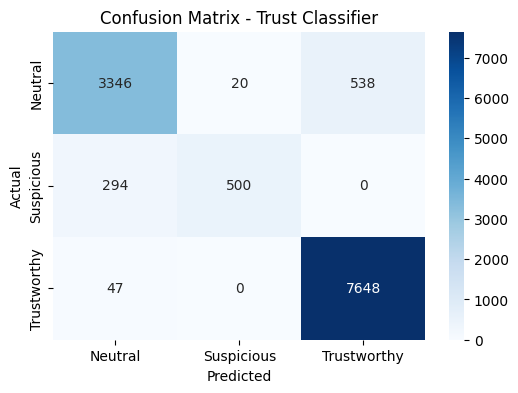

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rf_cl.classes_,
    yticklabels=rf_cl.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Trust Classifier")

plt.show()

In [73]:
from xgboost import XGBClassifier

In [74]:
from sklearn.preprocessing import LabelEncoder

In [75]:
le = LabelEncoder()

In [76]:
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [77]:
X.dtypes

host_age_days              float64
description_length           int64
amenities_count              int64
host_response_rate         float64
number_of_reviews            int64
review_scores_rating       float64
price_vs_avg               float64
sentiment_score            float64
price_volatility           float64
availability_ratio         float64
review_to_listing_ratio    float64
host_identity_verified     float64
host_has_profile_pic       float64
instant_bookable             int64
dtype: object

In [78]:
# convert price_vs_avg to float
#X["price_vs_avg"] = pd.to_numeric(X["price_vs_avg"], errors="coerce")
# fill missing values
#X["price_vs_avg"] = X["price_vs_avg"].fillna(0)

# make safe copy (important)
X = X.copy()

# convert to float safely
X.loc[:, "price_vs_avg"] = pd.to_numeric(X["price_vs_avg"], errors="coerce")

# fill missing values
X.loc[:, "price_vs_avg"] = X["price_vs_avg"].fillna(0)

In [79]:
X.dtypes

host_age_days              float64
description_length           int64
amenities_count              int64
host_response_rate         float64
number_of_reviews            int64
review_scores_rating       float64
price_vs_avg               float64
sentiment_score            float64
price_volatility           float64
availability_ratio         float64
review_to_listing_ratio    float64
host_identity_verified     float64
host_has_profile_pic       float64
instant_bookable             int64
dtype: object

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [81]:
xgb_cl = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_cl.fit(X_train, y_train_enc)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [82]:
xgb_pred_enc = xgb_cl.predict(X_test)
xgb_pred_enc

array([0, 2, 2, ..., 2, 0, 2], shape=(12393,))

In [83]:
xgb_pred = le.inverse_transform(xgb_pred_enc)
xgb_pred

array(['Neutral', 'Trustworthy', 'Trustworthy', ..., 'Trustworthy',
       'Neutral', 'Trustworthy'], shape=(12393,), dtype=object)

In [84]:
print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred, average="weighted"))

print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("Classification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost Results
Accuracy: 0.925038328088437
F1 Score: 0.9219661595176227
Confusion Matrix:
[[3327   24  553]
 [ 299  495    0]
 [  53    0 7642]]
Classification Report:
              precision    recall  f1-score   support

     Neutral       0.90      0.85      0.88      3904
  Suspicious       0.95      0.62      0.75       794
 Trustworthy       0.93      0.99      0.96      7695

    accuracy                           0.93     12393
   macro avg       0.93      0.82      0.86     12393
weighted avg       0.92      0.93      0.92     12393



In [85]:
comparison_cl = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [accuracy_score(y_test, rf_cl_pred), accuracy_score(y_test, xgb_pred)],
    "F1 Score": [f1_score(y_test, rf_cl_pred, average="weighted"), f1_score(y_test, xgb_pred, average="weighted")]
})

comparison_cl

,Model,Accuracy,F1 Score
0,Random Forest,0.927459,0.924510
1,XGBoost,0.925038,0.921966


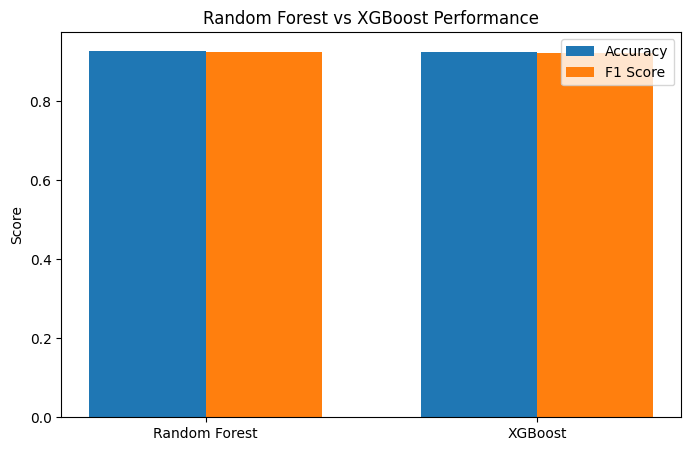

In [86]:
x = np.arange(len(comparison_cl["Model"]))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, comparison_cl["Accuracy"], width, label="Accuracy")
plt.bar(x + width/2, comparison_cl["F1 Score"], width, label="F1 Score")

plt.xticks(x, comparison_cl["Model"])

plt.ylabel("Score")
plt.title("Random Forest vs XGBoost Performance")

plt.legend()

plt.show()

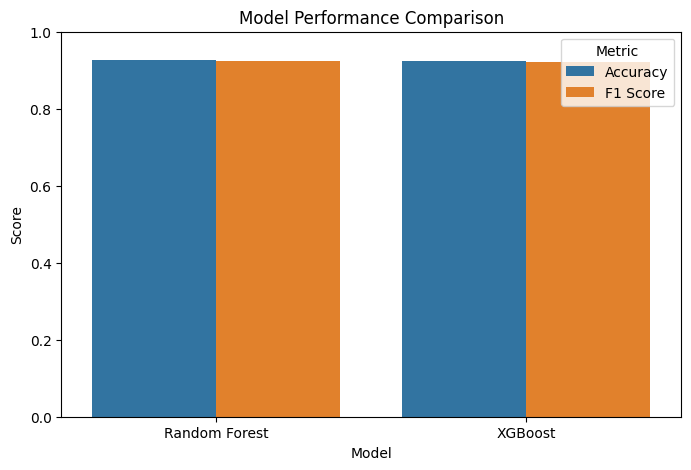

In [87]:
comparison_melted = comparison_cl.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.ylim(0,1)

plt.show()

In [88]:
xgb_f1 = f1_score(y_test, xgb_pred, average="weighted")
rf_f1 = f1_score(y_test, rf_cl_pred, average="weighted")

In [89]:
# choose best model based on F1 score
if xgb_f1 >= rf_f1:
    best_model = xgb_cl
    best_model_name = "XGBoost"
else:
    best_model = rf_cl
    best_model_name = "Random Forest"

print("Best Model:", best_model_name)

Best Model: Random Forest


In [90]:
import pickle

In [91]:
pickle.dump(xgb_cl, open("../models/trust_model_xgboost.pkl", "wb"))
pickle.dump(rf_cl, open("../models/trust_model_random_forest.pkl", "wb"))

In [92]:
# best model
pickle.dump(best_model, open("../models/best_model.pkl", "wb"))

In [93]:
pickle.dump(le, open("../models/label_encoder.pkl", "wb"))

# 2nd part - Regression Model

In [94]:
listi.columns

Index(['id', 'price', 'number_of_reviews', 'review_scores_rating',
       'host_identity_verified', 'host_has_profile_pic', 'host_response_rate',
       'latitude', 'longitude', 'description', 'amenities', 'accommodates',
       'bathrooms', 'bedrooms', 'room_type', 'property_type',
       'neighbourhood_cleansed', 'instant_bookable', 'host_age_days',
       'description_length', 'amenities_count', 'neighborhood_avg_price',
       'price_vs_avg', 'trust_label', 'review_to_listing_ratio',
       'sentiment_score', 'price_volatility', 'availability_ratio'],
      dtype='object')

In [95]:
listi["property_type_enc"] = listi["property_type"].astype("category").cat.codes

In [6]:
price_features = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "amenities_count",
    "room_type_enc",
    "neighbourhood_enc",
    "latitude",
    "longitude",
    "review_scores_rating",
    "availability_ratio"
]

removing extreme outliers using IQR

In [97]:
Q1 = listi["price"].quantile(0.25)
Q3 = listi["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

listi = listi[(listi["price"] >= lower_bound) & (listi["price"] <= upper_bound)]

In [98]:
# recreate encoded columns
listi["room_type_enc"] = listi["room_type"].astype("category").cat.codes

listi["neighbourhood_enc"] = listi["neighbourhood_cleansed"].astype("category").cat.codes

listi["property_type_enc"] = listi["property_type"].astype("category").cat.codes

In [99]:
listi.shape

(57768, 31)

In [100]:
listi["price"].dtype

dtype('O')

In [101]:
listi["price"] = pd.to_numeric(listi["price"], errors="coerce")

In [102]:
# input and target
X_price = listi[price_features]
y_price = listi["price"]

In [103]:
X_price.fillna(0)

,accommodates,bathrooms,bedrooms,amenities_count,room_type_enc,neighbourhood_enc,latitude,longitude,review_scores_rating,availability_ratio
0,1,1.0,1.0,55,2,18,51.568610,-0.112700,4.85,0.0
1,2,1.0,1.0,25,0,19,51.487800,-0.168130,4.80,0.0
2,6,2.0,3.0,39,0,32,51.521950,-0.140940,4.77,0.0
4,4,1.0,1.0,6,0,29,51.523220,-0.069790,4.53,0.0
5,5,1.5,3.0,34,0,26,51.481450,-0.281070,4.80,0.0
...,...,...,...,...,...,...,...,...,...,...
96866,2,2.0,2.0,25,0,18,51.526692,-0.097322,4.83,0.0
96867,2,1.0,1.0,9,0,31,51.429503,-0.165492,5.00,0.0
96868,4,1.0,1.0,11,0,0,51.529700,0.148890,4.83,0.0
96869,1,1.0,1.0,9,2,29,51.514600,-0.063140,4.83,0.0


In [104]:
X_price.shape

(57768, 10)

In [105]:
y_price.shape

(57768,)

In [106]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_price,
    y_price,
    test_size=0.2,
    random_state=42
)

In [107]:
from sklearn.ensemble import RandomForestRegressor

In [108]:
rf_reg = RandomForestRegressor(
    n_estimators=600,
    max_depth=25,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train_p, y_train_p)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [109]:
rf_reg_pred = rf_reg.predict(X_test_p)
rf_reg_pred 

array([132.03450732, 119.42111265,  96.44598304, ..., 182.51985575,
       197.31166667, 143.80068711], shape=(11554,))

In [110]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [111]:
print("MAE:", mean_absolute_error(y_test_p , rf_reg_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_p , rf_reg_pred)))
print("R2 Score:", r2_score(y_test_p , rf_reg_pred))

MAE: 35.853364417524595
RMSE: 51.3822876867578
R2 Score: 0.6935850230676595


In [112]:
from xgboost import XGBRegressor

In [113]:
xgb_reg = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_reg.fit(X_train_p, y_train_p)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [114]:
pred_xgb = xgb_reg.predict(X_test_p)
pred_xgb

array([ 54.59687, 104.05886,  90.06595, ..., 201.74126, 169.12708,
       153.27206], shape=(11554,), dtype=float32)

In [115]:
print("MAE:", mean_absolute_error(y_test_p , pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test_p , pred_xgb)))
print("R2 Score:", r2_score(y_test_p , pred_xgb))

MAE: 35.67540411031306
RMSE: 50.85966930668153
R2 Score: 0.6997865259401869


In [118]:
pickle.dump(rf_reg, open("../models/price_model_random_forest.pkl", "wb"))
pickle.dump(xgb_reg, open("../models/price_model_xgboost.pkl", "wb"))

C:\Users\Sakalni\AppData\Local\Temp\ipykernel_540\4085347715.py:1: ResourceWarning: unclosed file <_io.BufferedWriter name='../models/price_model_random_forest.pkl'>
  pickle.dump(rf_reg, open("../models/price_model_random_forest.pkl", "wb"))
C:\Users\Sakalni\AppData\Local\Temp\ipykernel_540\4085347715.py:2: ResourceWarning: unclosed file <_io.BufferedWriter name='../models/price_model_xgboost.pkl'>
  pickle.dump(xgb_reg, open("../models/price_model_xgboost.pkl", "wb"))


In [119]:
with open("../models/price_model_random_forest.pkl", "wb") as f:
    pickle.dump(rf_reg, f)

with open("../models/price_model_xgboost.pkl", "wb") as f:
    pickle.dump(xgb_reg, f)

In [120]:
rf_r2 =  r2_score(y_test_p , rf_reg_pred)
xgb_r2 = r2_score(y_test_p , pred_xgb)

In [121]:
if xgb_r2 >= rf_r2:
    best_price_model = xgb_reg
    best_model_name= "XGBoost"
else:
    best_price_model = xf_reg
    best_model_name= "Random Forest"

In [122]:
pickle.dump(best_price_model, open("../models/best_price_model.pkl", "wb"))
print("Best Model Name : ",best_model_name)

Best Model Name :  XGBoost


C:\Users\Sakalni\AppData\Local\Temp\ipykernel_540\849698211.py:1: ResourceWarning: unclosed file <_io.BufferedWriter name='../models/best_price_model.pkl'>
  pickle.dump(best_price_model, open("../models/best_price_model.pkl", "wb"))


In [123]:
with open("../models/best_price_model.pkl", "wb") as f:
    pickle.dump(best_price_model, f)

In [126]:
X.to_csv("trust_features_data.csv", index=False)

In [3]:
## Save Trust Feature Columns

In [10]:
pickle.dump(trust_features, open("../models/trust_feature_columns.pkl", "wb"))

## Save Price Feature Columns

In [11]:
pickle.dump(price_features, open("../models/price_feature_columns.pkl", "wb"))